In [4]:
import numpy as np
import xarray as xr
import matplotlib as plt
import xrft as xt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.tsa.seasonal import STL


ds1=xr.open_dataset('amp_ph_ssp585_r1.nc').squeeze()
ds2=xr.open_dataset('amp_ph_ssp245_r1.nc').squeeze()
ds3=xr.open_dataset('amp_ph_ssp126_r1.nc').squeeze()

# ds1.squeeze()
# ds1 = ds1.sel(time=slice('1985', '2100'))#.mean(['lat', 'lon'])

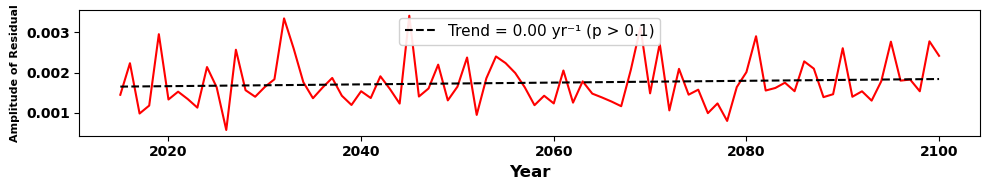

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load dataset and extract the internal variability variable
# ds1 = xr.open_dataset('amp_ssp585_2015-2100.nc').squeeze()

# Assume there's only one variable in the dataset
var1 = ds1.to_array().squeeze()

# Extract time and values
time1 = ds1['year'].values
data1 = var1.values

# Linear regression for SSP5-8.5
slope1, intercept1, r1, p1, _ = linregress(time1, data1)
trend1 = slope1 * time1 + intercept1

# Plotting
plt.figure(figsize=(10, 2))
plt.plot(time1, data1, color='red')
plt.plot(time1, trend1, linestyle='--', color='black',
         label=f'Trend = 0.00 yr⁻¹ (p > 0.1)')

# Axis labels with bold formatting
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Amplitude of Residual', fontsize=8, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Legend in the upper center
plt.legend(loc='upper center', fontsize=11, frameon=True, fancybox=True, framealpha=0.9)

# Remove gridlines
plt.grid(False)
plt.tight_layout()
plt.show()


/tmp/ipykernel_13229/184197767.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_yticklabels(axs[0].get_yticks(), fontweight='bold')
/tmp/ipykernel_13229/184197767.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_yticklabels(axs[1].get_yticks(), fontweight='bold')
/tmp/ipykernel_13229/184197767.py:103: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_yticklabels(axs[2].get_yticks(), fontweight='bold')


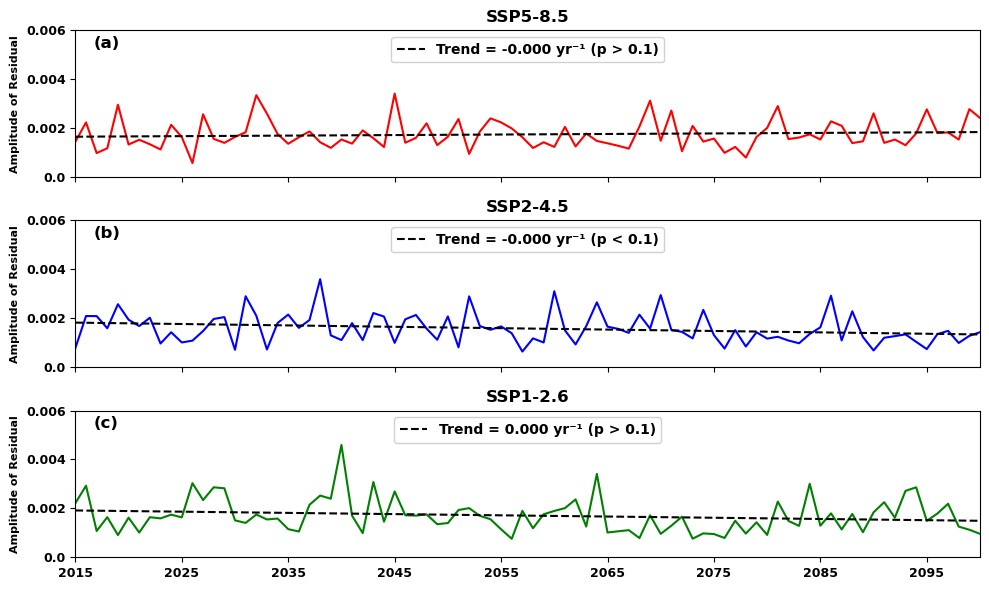

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import FontProperties



# Convert datasets to variables (assuming each has one variable)
var1 = ds1.to_array().squeeze()
var2 = ds2.to_array().squeeze()
var3 = ds3.to_array().squeeze()

# Extract time and values
time1 = ds1['year'].values
time2 = ds2['year'].values
time3 = ds3['year'].values

data1 = var1.values
data2 = var2.values
data3 = var3.values

# Linear regression for each SSP
slope1, intercept1, r1, p1, _ = linregress(time1, data1)
trend1 = slope1 * time1 + intercept1

slope2, intercept2, r2, p2, _ = linregress(time2, data2)
trend2 = slope2 * time2 + intercept2

slope3, intercept3, r3, p3, _ = linregress(time3, data3)
trend3 = slope3 * time3 + intercept3

# Plotting: 3 subplots (3 rows, 1 column)
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

# Common y- and x-axis limits
y_min, y_max = 0, 0.006
x_min, x_max = 2015, 2100
x_ticks = np.arange(x_min, x_max + 1, 10)

# Bold font for legend
bold_font = FontProperties(weight='bold')

# Formatter for x-axis ticks to remove decimal points
def int_fmt(x, _): return f'{int(x)}'
int_formatter = FuncFormatter(int_fmt)

# Plot SSP5-8.5
axs[0].plot(time1, data1, color='red')
axs[0].plot(time1, trend1, linestyle='--', color='black',
            label=f'Trend = -0.000 yr⁻¹ (p > 0.1)')
axs[0].set_ylim(y_min, y_max)
axs[0].set_xlim(x_min, x_max)
axs[0].set_xticks(x_ticks)
axs[0].xaxis.set_major_formatter(int_formatter)

axs[0].set_ylabel('Amplitude of Residual', fontsize=8, fontweight='bold')
axs[0].legend(loc='upper center', fontsize=9, prop=bold_font,
              frameon=True, fancybox=True, framealpha=0.9)
axs[0].tick_params(axis='both', labelsize=9)
axs[0].set_title('SSP5-8.5', fontsize=12, fontweight='bold')
axs[0].set_yticklabels(axs[0].get_yticks(), fontweight='bold')
axs[0].text(0.02, 0.96, '(a)', transform=axs[0].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[0].grid(False)

# Plot SSP2-4.5
axs[1].plot(time2, data2, color='blue')
axs[1].plot(time2, trend2, linestyle='--', color='black',
            label=f'Trend = -0.000 yr⁻¹ (p < 0.1)')
axs[1].set_ylim(y_min, y_max)
axs[1].set_xlim(x_min, x_max)
axs[1].set_xticks(x_ticks)
axs[1].xaxis.set_major_formatter(int_formatter)

axs[1].set_ylabel('Amplitude of Residual', fontsize=8, fontweight='bold')
axs[1].legend(loc='upper center', fontsize=9, prop=bold_font,
              frameon=True, fancybox=True, framealpha=0.9)
axs[1].tick_params(axis='both', labelsize=9)
axs[1].set_title('SSP2-4.5', fontsize=12, fontweight='bold')
axs[1].set_yticklabels(axs[1].get_yticks(), fontweight='bold')
axs[1].text(0.02, 0.96, '(b)', transform=axs[1].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[1].grid(False)

# Plot SSP1-2.6
axs[2].plot(time3, data3, color='green')
axs[2].plot(time3, trend3, linestyle='--', color='black',
            label=f'Trend = 0.000 yr⁻¹ (p > 0.1)')
axs[2].set_ylim(y_min, y_max)
axs[2].set_xlim(x_min, x_max)
axs[2].set_xticks(x_ticks)
axs[2].xaxis.set_major_formatter(int_formatter)

# axs[2].set_xlabel('Year', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Amplitude of Residual', fontsize=8, fontweight='bold')
axs[2].legend(loc='upper center', fontsize=9, prop=bold_font,
              frameon=True, fancybox=True, framealpha=0.9)
axs[2].tick_params(axis='both', labelsize=9)
axs[2].set_title('SSP1-2.6', fontsize=12, fontweight='bold')
axs[2].set_xticklabels(axs[2].get_xticks(), fontweight='bold')
axs[2].set_yticklabels(axs[2].get_yticks(), fontweight='bold')
axs[2].text(0.02, 0.96, '(c)', transform=axs[2].transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')
axs[2].grid(False)

plt.tight_layout()
plt.savefig('pH_amplitude_residual_review_f2.png', bbox_inches='tight', dpi=600)

plt.show()
